In [1]:
from google.colab import files
files.upload()  # Upload kaggle.json

# Move the uploaded file to the correct location
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/




Saving kaggle.json to kaggle.json


In [2]:
#!/bin/bash
!kaggle datasets download williamscott701/memotion-dataset-7k

Dataset URL: https://www.kaggle.com/datasets/williamscott701/memotion-dataset-7k
License(s): other
 99% 689M/695M [00:03<00:00, 45.1MB/s]
100% 695M/695M [00:03<00:00, 185MB/s] 


In [3]:
!unzip /content/memotion-dataset-7k.zip

Streaming output truncated to the last 5000 lines.
  inflating: memotion_dataset_7k/images/image_2798.png  
  inflating: memotion_dataset_7k/images/image_2799.png  
  inflating: memotion_dataset_7k/images/image_28.jpg  
  inflating: memotion_dataset_7k/images/image_280.jpg  
  inflating: memotion_dataset_7k/images/image_2800.png  
  inflating: memotion_dataset_7k/images/image_2801.png  
  inflating: memotion_dataset_7k/images/image_2802.png  
  inflating: memotion_dataset_7k/images/image_2803.png  
  inflating: memotion_dataset_7k/images/image_2804.png  
  inflating: memotion_dataset_7k/images/image_2805.jpg  
  inflating: memotion_dataset_7k/images/image_2806.jpg  
  inflating: memotion_dataset_7k/images/image_2807.jpg  
  inflating: memotion_dataset_7k/images/image_2808.jpg  
  inflating: memotion_dataset_7k/images/image_2809.png  
  inflating: memotion_dataset_7k/images/image_281.png  
  inflating: memotion_dataset_7k/images/image_2810.jpg  
  inflating: memotion_dataset_7k/images/i

In [9]:
import os

print("Files in /content:\n")
for f in os.listdir("/content"):
    print(f)

Files in /content:

.config
memotion-dataset-7k.zip
memotion_dataset_7k
sample_data


In [10]:
import pandas as pd
import os

# Paths
LABELS_PATH = "/content/memotion_dataset_7k/labels.csv"
IMAGES_DIR = "/content/memotion_dataset_7k/images"

# Load labels
df = pd.read_csv(LABELS_PATH)

print("Total rows (original):", len(df))

# Keep required columns
df = df[
    [
        "image_name",
        "text_ocr",
        "overall_sentiment",
        "humour",
        "sarcasm",
        "offensive",
        "motivational",
    ]
]

# Remove bad text rows
df = df.dropna(subset=["text_ocr"])
df = df[df["text_ocr"].astype(str).str.strip() != ""]

# Create image_path
df["image_path"] = df["image_name"].apply(
    lambda x: os.path.join(IMAGES_DIR, x)
)

# Remove rows with missing images
df = df[df["image_path"].apply(os.path.isfile)]

print("Rows after text + image cleaning:", len(df))

# Save clean dataset
FINAL_PATH = "/content/memotion_clean.csv"
df.to_csv(FINAL_PATH, index=False)

print("✅ Clean dataset saved at:", FINAL_PATH)

Total rows (original): 6992
Rows after text + image cleaning: 6831
✅ Clean dataset saved at: /content/memotion_clean.csv


In [11]:
import pandas as pd
import os

# Load already text-cleaned dataset
df = pd.read_csv("/content/memotion_clean.csv")

print("Rows before image check:", len(df))

# Remove rows where image file is missing or path is invalid
df = df[df["image_path"].apply(lambda x: isinstance(x, str) and os.path.isfile(x))]

print("Rows after image check:", len(df))

# Save FINAL dataset
FINAL_PATH = "/content/memotion_final_train.csv"
df.to_csv(FINAL_PATH, index=False)

print("✅ FINAL training dataset saved at:", FINAL_PATH)

Rows before image check: 6831
Rows after image check: 6831
✅ FINAL training dataset saved at: /content/memotion_final_train.csv


In [13]:
import pandas as pd

# Load full clean dataset
df = pd.read_csv("/content/memotion_final_train.csv")
print("Total rows available:", len(df))

# Randomly sample 1500 rows
df_1500 = df.sample(n=1500, random_state=42).reset_index(drop=True)

print("Rows after sampling:", len(df_1500))

# Save 1500-sample dataset
SAMPLE_PATH = "/content/memotion_1500_train.csv"
df_1500.to_csv(SAMPLE_PATH, index=False)

print("✅ 1500-sample dataset saved at:", SAMPLE_PATH)

Total rows available: 6831
Rows after sampling: 1500
✅ 1500-sample dataset saved at: /content/memotion_1500_train.csv


In [14]:
import pandas as pd
import json
from sklearn.preprocessing import LabelEncoder

# Load 1500-sample dataset
DATA_PATH = "/content/memotion_1500_train.csv"
df = pd.read_csv(DATA_PATH)

print("Loaded rows:", len(df))

# -----------------------------
# 1) Convert sentiment to 3-class
# -----------------------------
sentiment_map = {
    "very_negative": "negative",
    "negative": "negative",
    "neutral": "neutral",
    "positive": "positive",
    "very_positive": "positive",
}

df["sentiment_3"] = df["overall_sentiment"].map(sentiment_map)

# -----------------------------
# 2) Encode labels
# -----------------------------
label_maps = {}

def encode_column(df, col):
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col])
    label_maps[col] = {cls: int(idx) for cls, idx in zip(le.classes_, le.transform(le.classes_))}
    return df

for col in ["humour", "sarcasm", "offensive", "motivational"]:
    df = encode_column(df, col)

# Encode sentiment (3-class)
le_sent = LabelEncoder()
df["sentiment_enc"] = le_sent.fit_transform(df["sentiment_3"])
label_maps["sentiment_3"] = {
    cls: int(idx) for cls, idx in zip(le_sent.classes_, le_sent.transform(le_sent.classes_))
}

# -----------------------------
# 3) Keep only required columns
# -----------------------------
df_final = df[
    [
        "image_path",
        "text_ocr",
        "sentiment_enc",
        "humour_enc",
        "sarcasm_enc",
        "offensive_enc",
        "motivational_enc",
    ]
]

print("Final encoded shape:", df_final.shape)

# -----------------------------
# 4) Save encoded dataset + maps
# -----------------------------
ENCODED_PATH = "/content/memotion_1500_encoded.csv"
MAP_PATH = "/content/memotion_label_maps.json"

df_final.to_csv(ENCODED_PATH, index=False)

with open(MAP_PATH, "w") as f:
    json.dump(label_maps, f, indent=2)

print("✅ Saved:")
print(ENCODED_PATH)
print(MAP_PATH)

Loaded rows: 1500
Final encoded shape: (1500, 7)
✅ Saved:
/content/memotion_1500_encoded.csv
/content/memotion_label_maps.json


In [15]:
# ============================================================
# STEP 3: PyTorch Dataset & DataLoader (SAFE)
# ============================================================

!pip install -q transformers timm

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
from transformers import AutoTokenizer

# --------------------
# Config
# --------------------
DATA_PATH = "/content/memotion_1500_encoded.csv"
TOKENIZER_NAME = "bert-base-uncased"
IMG_SIZE = 224
MAX_LEN = 64
BATCH_SIZE = 8

# --------------------
# Load dataset
# --------------------
df = pd.read_csv(DATA_PATH)
print("Loaded rows:", len(df))
display(df.head(3))

# --------------------
# Image transforms
# --------------------
img_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# --------------------
# Tokenizer
# --------------------
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)

# --------------------
# Dataset
# --------------------
class MemotionDataset(Dataset):
    def __init__(self, df, tokenizer, transform, max_len):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Image
        image = Image.open(row["image_path"]).convert("RGB")
        image = self.transform(image)

        # Text (guaranteed string at this point)
        text = str(row["text_ocr"])

        enc = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt",
        )
        enc = {k: v.squeeze(0) for k, v in enc.items()}

        labels = {
            "sentiment": torch.tensor(row["sentiment_enc"], dtype=torch.long),
            "humour": torch.tensor(row["humour_enc"], dtype=torch.long),
            "sarcasm": torch.tensor(row["sarcasm_enc"], dtype=torch.long),
            "offensive": torch.tensor(row["offensive_enc"], dtype=torch.long),
            "motivational": torch.tensor(row["motivational_enc"], dtype=torch.long),
        }

        return {
            "image": image,
            "input_ids": enc["input_ids"],
            "attention_mask": enc["attention_mask"],
            "labels": labels,
        }

# --------------------
# DataLoader
# --------------------
dataset = MemotionDataset(df, tokenizer, img_transform, MAX_LEN)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# --------------------
# Sanity check
# --------------------
batch = next(iter(loader))

print("\nSANITY CHECK")
print("Images:", batch["image"].shape)
print("Input IDs:", batch["input_ids"].shape)
print("Attention mask:", batch["attention_mask"].shape)
for k, v in batch["labels"].items():
    print(k, v.shape)

Loaded rows: 1500


,image_path,text_ocr,sentiment_enc,humour_enc,sarcasm_enc,offensive_enc,motivational_enc
0,/content/memotion_dataset_7k/images/image_4829...,WINED A LOT BUT DID,1,1,2,2,1
1,/content/memotion_dataset_7k/images/image_2113...,KILLED MORE PEOPLE THAN HITLER UHH... WHO ARE ...,1,2,0,3,1
2,/content/memotion_dataset_7k/images/image_5093...,Hey girl. The post-feminist fetishization of m...,2,2,0,1,0



SANITY CHECK
Images: torch.Size([8, 3, 224, 224])
Input IDs: torch.Size([8, 64])
Attention mask: torch.Size([8, 64])
sentiment torch.Size([8])
humour torch.Size([8])
sarcasm torch.Size([8])
offensive torch.Size([8])
motivational torch.Size([8])


In [16]:
# ============================================================
# STEP 4: Multimodal Model (ResNet50 + BERT + Fusion)
# ============================================================

!pip install -q transformers timm

import torch
import torch.nn as nn
import torchvision.models as models
from transformers import AutoModel

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# --------------------
# Vision Encoder
# --------------------
class VisionEncoder(nn.Module):
    def __init__(self, out_dim):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        self.proj = nn.Sequential(
            nn.Linear(2048, out_dim),
            nn.LayerNorm(out_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        x = self.features(x).squeeze(-1).squeeze(-1)
        return self.proj(x)

# --------------------
# Text Encoder
# --------------------
class TextEncoder(nn.Module):
    def __init__(self, model_name, out_dim):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.proj = nn.Sequential(
            nn.Linear(768, out_dim),
            nn.LayerNorm(out_dim),
            nn.ReLU(),
        )

    def forward(self, input_ids, attention_mask):
        out = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
        ).last_hidden_state[:, 0]  # CLS token
        return self.proj(out)

# --------------------
# Multimodal Fusion Model
# --------------------
class MultimodalModel(nn.Module):
    def __init__(self, dim=256):
        super().__init__()
        self.vision = VisionEncoder(dim)
        self.text = TextEncoder("bert-base-uncased", dim)

        # Learnable gated fusion
        self.gate = nn.Linear(dim * 2, dim)

        # Task heads
        self.sentiment = nn.Linear(dim, 3)
        self.humour = nn.Linear(dim, 4)
        self.sarcasm = nn.Linear(dim, 4)
        self.offensive = nn.Linear(dim, 4)
        self.motivational = nn.Linear(dim, 2)

    def forward(self, image, input_ids, attention_mask):
        v = self.vision(image)
        t = self.text(input_ids, attention_mask)

        h = torch.cat([v, t], dim=1)
        g = torch.sigmoid(self.gate(h))
        fused = g * v + (1 - g) * t

        return {
            "sentiment": self.sentiment(fused),
            "humour": self.humour(fused),
            "sarcasm": self.sarcasm(fused),
            "offensive": self.offensive(fused),
            "motivational": self.motivational(fused),
        }

# --------------------
# Forward-pass sanity check
# --------------------
model = MultimodalModel(dim=256).to(DEVICE)
model.eval()

batch = next(iter(loader))

with torch.no_grad():
    outputs = model(
        batch["image"].to(DEVICE),
        batch["input_ids"].to(DEVICE),
        batch["attention_mask"].to(DEVICE),
    )

print("\nFORWARD PASS CHECK:")
for k, v in outputs.items():
    print(k, v.shape)

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 183MB/s]


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]


FORWARD PASS CHECK:
sentiment torch.Size([8, 3])
humour torch.Size([8, 4])
sarcasm torch.Size([8, 4])
offensive torch.Size([8, 4])
motivational torch.Size([8, 2])


In [18]:
# ============================================================
# STEP 5: Training Loop (Multi-task)
# ============================================================

import torch
import torch.nn as nn
from torch.optim import AdamW
from sklearn.model_selection import train_test_split

# --------------------
# Train / Val split
# --------------------
train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["sentiment_enc"]
)

train_dataset = MemotionDataset(train_df, tokenizer, img_transform, MAX_LEN)
val_dataset   = MemotionDataset(val_df, tokenizer, img_transform, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"Train samples: {len(train_df)} | Val samples: {len(val_df)}")

# --------------------
# Losses
# --------------------
criterion = {
    "sentiment": nn.CrossEntropyLoss(),
    "humour": nn.CrossEntropyLoss(),
    "sarcasm": nn.CrossEntropyLoss(),
    "offensive": nn.CrossEntropyLoss(),
    "motivational": nn.CrossEntropyLoss(),
}

# --------------------
# Optimizer
# --------------------
optimizer = AdamW(model.parameters(), lr=2e-5)

# --------------------
# Training
# --------------------
EPOCHS = 2
model.train()

for epoch in range(EPOCHS):
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        outputs = model(
            batch["image"].to(DEVICE),
            batch["input_ids"].to(DEVICE),
            batch["attention_mask"].to(DEVICE),
        )

        loss = (
            1.5 * criterion["sentiment"](outputs["sentiment"], batch["labels"]["sentiment"].to(DEVICE)) +
            criterion["humour"](outputs["humour"], batch["labels"]["humour"].to(DEVICE)) +
            criterion["sarcasm"](outputs["sarcasm"], batch["labels"]["sarcasm"].to(DEVICE)) +
            criterion["offensive"](outputs["offensive"], batch["labels"]["offensive"].to(DEVICE)) +
            criterion["motivational"](outputs["motivational"], batch["labels"]["motivational"].to(DEVICE))
        )

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {total_loss/len(train_loader):.4f}")

Train samples: 1200 | Val samples: 300


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/2] - Train Loss: 5.7641
Epoch [2/2] - Train Loss: 5.4045


In [19]:
# ============================================================
# STEP 6: Save Model
# ============================================================

SAVE_PATH = "/content/memotion_multimodal_model.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "tokenizer": "bert-base-uncased",
    "img_size": 224,
    "max_len": 64,
    "label_maps": "/content/memotion_label_maps.json"
}, SAVE_PATH)

print("✅ Model saved at:", SAVE_PATH)

✅ Model saved at: /content/memotion_multimodal_model.pth


In [22]:
from google.colab import files

files.download("/content/memotion_multimodal_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
from sklearn.metrics import accuracy_score

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for batch in val_loader:
        outputs = model(
            batch["image"].to(DEVICE),
            batch["input_ids"].to(DEVICE),
            batch["attention_mask"].to(DEVICE),
        )

        preds = outputs["sentiment"].argmax(dim=1).cpu().numpy()
        labels = batch["labels"]["sentiment"].cpu().numpy()

        y_true.extend(labels)
        y_pred.extend(preds)

acc = accuracy_score(y_true, y_pred)
print(f"✅ Validation Sentiment Accuracy: {acc:.3f}")

✅ Validation Sentiment Accuracy: 0.567


In [37]:
import json

with open("/content/memotion_label_maps.json", "r") as f:
    label_maps = json.load(f)

# Reverse maps: encoded → text label
rev_maps = {
    task: {v: k for k, v in mapping.items()}
    for task, mapping in label_maps.items()
}

print("✅ rev_maps loaded")

✅ rev_maps loaded


In [38]:
from PIL import Image
import torch

def predict_meme(image_path, text):
    model.eval()

    # Image
    image = Image.open(image_path).convert("RGB")
    image = img_transform(image).unsqueeze(0).to(DEVICE)

    # Text
    enc = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt",
    )
    enc = {k: v.to(DEVICE) for k, v in enc.items()}

    with torch.no_grad():
        outputs = model(image, enc["input_ids"], enc["attention_mask"])

    preds = {}
    for task, logits in outputs.items():
        pred_id = logits.argmax(dim=1).item()
        preds[task] = rev_maps[task][pred_id]

    return preds

🚀 FUNCTION STARTED
Total rows: 1500

================ SAMPLE =================
Index: 1117
IMAGE PATH: /content/memotion_dataset_7k/images/image_331.jpg


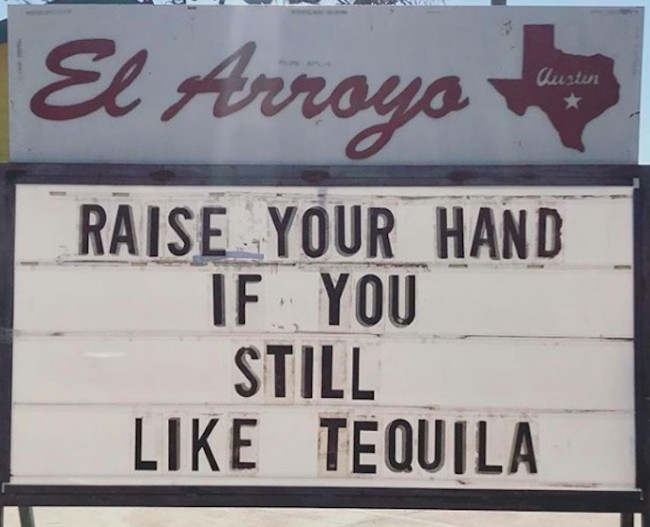


📝 TEXT:
El Arroyo Gustin RAISE YOUR HAND IF YOU STILL LIKE TEQUILA OF YOU HAND

✅ GROUND TRUTH:
❌ GT error: 'sentiment'

🔮 MODEL PREDICTION:
❌ Prediction error: 'sentiment'


In [39]:
test_on_dataset_samples(df, n_samples=1)

In [41]:
print("rev_maps keys:", rev_maps.keys())

rev_maps keys: dict_keys(['humour', 'sarcasm', 'offensive', 'motivational', 'sentiment_3'])


In [42]:
from IPython.display import display
from PIL import Image

def test_on_dataset_samples(df, n_samples=1):
    print("🚀 FUNCTION STARTED")
    print("Total rows:", len(df))

    model.eval()
    samples = df.sample(n_samples)

    for idx, row in samples.iterrows():
        print("\n================ SAMPLE =================")
        print("Index:", idx)
        print("IMAGE PATH:", row["image_path"])

        # ---- IMAGE ----
        img = Image.open(row["image_path"]).convert("RGB")
        display(img)

        # ---- TEXT ----
        print("\n📝 TEXT:")
        print(row["text_ocr"])

        # ---- GROUND TRUTH (FIXED KEYS) ----
        print("\n✅ GROUND TRUTH:")
        print("sentiment:", rev_maps["sentiment_enc"][row["sentiment_enc"]])
        print("humour:", rev_maps["humour_enc"][row["humour_enc"]])
        print("sarcasm:", rev_maps["sarcasm_enc"][row["sarcasm_enc"]])
        print("offensive:", rev_maps["offensive_enc"][row["offensive_enc"]])
        print("motivational:", rev_maps["motivational_enc"][row["motivational_enc"]])

        # ---- MODEL PREDICTION ----
        print("\n🔮 MODEL PREDICTION:")
        preds = predict_meme(row["image_path"], row["text_ocr"])
        for k, v in preds.items():
            print(f"{k}: {v}")

        print("========================================")

In [43]:
from IPython.display import display
from PIL import Image

def test_on_dataset_samples(df, n_samples=1):
    print("🚀 FUNCTION STARTED")
    print("Total rows:", len(df))

    model.eval()
    samples = df.sample(n_samples)

    for idx, row in samples.iterrows():
        print("\n================ SAMPLE =================")
        print("Index:", idx)
        print("IMAGE PATH:", row["image_path"])

        # ---- IMAGE ----
        img = Image.open(row["image_path"]).convert("RGB")
        display(img)

        # ---- TEXT ----
        print("\n📝 TEXT:")
        print(row["text_ocr"])

        # ---- GROUND TRUTH (FIXED) ----
        print("\n✅ GROUND TRUTH:")
        print("sentiment:", rev_maps["sentiment_3"][row["sentiment_enc"]])
        print("humour:", rev_maps["humour"][row["humour_enc"]])
        print("sarcasm:", rev_maps["sarcasm"][row["sarcasm_enc"]])
        print("offensive:", rev_maps["offensive"][row["offensive_enc"]])
        print("motivational:", rev_maps["motivational"][row["motivational_enc"]])

        # ---- MODEL PREDICTION ----
        print("\n🔮 MODEL PREDICTION:")
        preds = predict_meme(row["image_path"], row["text_ocr"])
        for k, v in preds.items():
            print(f"{k}: {v}")

        print("========================================")

In [45]:
def predict_meme(image_path, text):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image = img_transform(image).unsqueeze(0).to(DEVICE)

    enc = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt",
    )
    enc = {k: v.to(DEVICE) for k, v in enc.items()}

    with torch.no_grad():
        outputs = model(image, enc["input_ids"], enc["attention_mask"])

    preds = {}
    for task, logits in outputs.items():
        pred_id = logits.argmax(dim=1).item()
        map_key = "sentiment_3" if task == "sentiment" else task
        preds[task] = rev_maps[map_key][pred_id]

    return preds

🚀 FUNCTION STARTED
Total rows: 1500

================ SAMPLE =================
Index: 1439
IMAGE PATH: /content/memotion_dataset_7k/images/image_1548.jpg


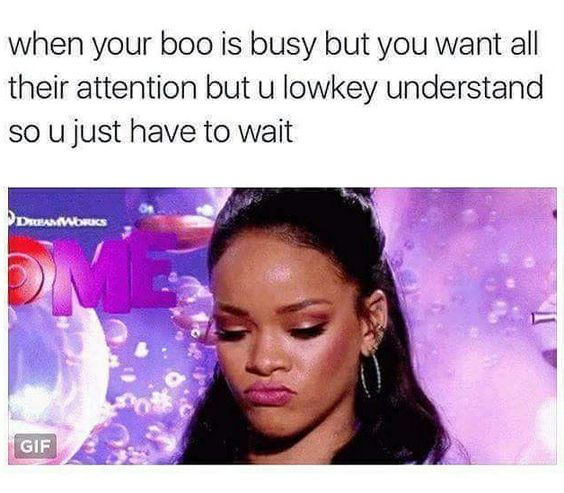


📝 TEXT:
when your boo is busy but you want all their attention but u lowkey understand so u just have to wait DECHANIWcs GIF

✅ GROUND TRUTH:
sentiment: positive
humour: very_funny
sarcasm: general
offensive: very_offensive
motivational: motivational

🔮 MODEL PREDICTION:
sentiment: positive
humour: very_funny
sarcasm: general
offensive: not_offensive
motivational: not_motivational


In [46]:
test_on_dataset_samples(df, n_samples=1)